In [1]:
print("Notebook Working Successfully")

Notebook Working Successfully


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# Customer Intelligence & Segmentation Platform

## Notebook 01: Data Cleaning & Data Quality Assessment

### Objective

This notebook performs:

- Data loading
- Data quality assessment
- Missing value analysis
- Duplicate detection
- Transaction validation
- Revenue feature creation
- Clean dataset export

The cleaned dataset will be used for customer analytics and segmentation.

In [8]:
df = pd.read_excel("../data/raw/Online Retail.xlsx")

print("Dataset Loaded Successfully")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

df.head()

Dataset Loaded Successfully
Rows: 541,909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

df.info()

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [10]:
print("Dataset Shape")
print(df.shape)

Dataset Shape
(541909, 8)


In [11]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


In [12]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates:,}")

Duplicate Records: 5,268


In [13]:
print("Unique Customers:", df["CustomerID"].nunique())
print("Unique Products:", df["StockCode"].nunique())
print("Countries:", df["Country"].nunique())
print("Invoices:", df["InvoiceNo"].nunique())

Unique Customers: 4372
Unique Products: 4070
Countries: 38
Invoices: 25900


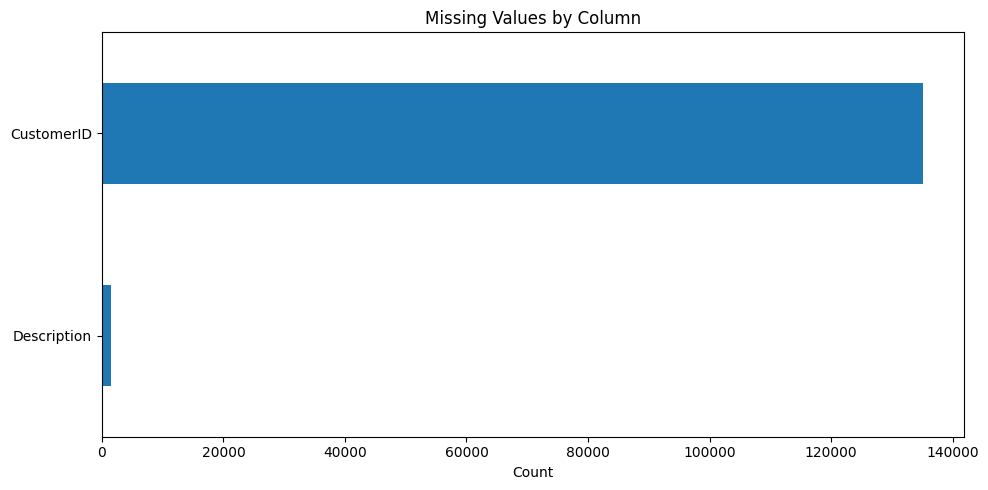

In [14]:
plt.figure(figsize=(10,5))

missing = df.isnull().sum()
missing = missing[missing > 0]

missing.sort_values().plot(kind="barh")

plt.title("Missing Values by Column")
plt.xlabel("Count")
plt.tight_layout()

plt.show()

# Data Cleaning Pipeline

This section prepares the transactional dataset for customer analytics by:

- Removing missing Customer IDs
- Removing duplicate transactions
- Removing cancelled invoices
- Removing invalid quantities
- Removing invalid prices
- Creating revenue metrics

In [15]:
df_clean = df.copy()

print("Backup Created")

Backup Created


In [16]:
before_rows = len(df_clean)

df_clean = df_clean.dropna(subset=["CustomerID"])

after_rows = len(df_clean)

print(f"Rows Before: {before_rows:,}")
print(f"Rows After : {after_rows:,}")
print(f"Rows Removed: {before_rows - after_rows:,}")

Rows Before: 541,909
Rows After : 406,829
Rows Removed: 135,080


In [17]:
before_rows = len(df_clean)

df_clean = df_clean.drop_duplicates()

after_rows = len(df_clean)

print(f"Rows Before: {before_rows:,}")
print(f"Rows After : {after_rows:,}")
print(f"Duplicates Removed: {before_rows - after_rows:,}")

Rows Before: 406,829
Rows After : 401,604
Duplicates Removed: 5,225


In [18]:
before_rows = len(df_clean)

df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
]

after_rows = len(df_clean)

print(f"Cancelled Transactions Removed: {before_rows - after_rows:,}")

Cancelled Transactions Removed: 8,872


In [19]:
before_rows = len(df_clean)

df_clean = df_clean[df_clean["Quantity"] > 0]

after_rows = len(df_clean)

print(f"Invalid Quantities Removed: {before_rows - after_rows:,}")

Invalid Quantities Removed: 0


In [20]:
before_rows = len(df_clean)

df_clean = df_clean[df_clean["UnitPrice"] > 0]

after_rows = len(df_clean)

print(f"Invalid Prices Removed: {before_rows - after_rows:,}")

Invalid Prices Removed: 40


In [21]:
df_clean["Revenue"] = (
    df_clean["Quantity"] *
    df_clean["UnitPrice"]
)

df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [22]:
df_clean["CustomerID"] = (
    df_clean["CustomerID"]
    .astype(int)
)

In [23]:
print("=" * 50)
print("FINAL CLEAN DATASET")
print("=" * 50)

print("Shape:", df_clean.shape)
print()

print("Missing Values")
print(df_clean.isnull().sum())

FINAL CLEAN DATASET
Shape: (392692, 9)

Missing Values
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64


In [24]:
print("Total Revenue")
print(f"${df_clean['Revenue'].sum():,.2f}")

print()
print("Average Transaction Value")
print(f"${df_clean['Revenue'].mean():,.2f}")

Total Revenue
$8,887,208.89

Average Transaction Value
$22.63


In [25]:
df_clean.to_csv(
    "../data/processed/cleaned_data.csv",
    index=False
)

print("cleaned_data.csv saved successfully")

cleaned_data.csv saved successfully


# Data Quality Report

## Cleaning Summary

The following preprocessing steps were performed:

- Removed transactions without Customer ID
- Removed duplicate transactions
- Removed cancelled invoices
- Removed transactions with non-positive prices
- Created Revenue feature

## Final Dataset

The cleaned dataset is now suitable for:

- Customer analytics
- RFM analysis
- Customer segmentation
- Customer lifetime value estimation
- Business intelligence reporting